In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch 

In [68]:
from src.data_generators import  generate_x_grid, generate_var3_3d, true_var3_3d_conditional_density
from src.rho_estimation import estimate_rho_grid
from src.r_bp import R_BP_density, kde_initial, fit_R_BP_marginals_until_t
from src.transform import X_to_U
from src.lag import lagged_k_U
from src.copula import fit_conditional_vines, estimate_gaussian_clayton_gas, compute_time_varying_copula_paths, compute_time_varying_copula_paths
from src.conditional_density import conditional_marginal_all, build_u_tilde_data, conditional_marginal_pdf, conditional_marginal_cdf
from src.predictive_density import predictive_density
from src.var3_true import true_var3_3d_conditional_mean, true_var3_3d_conditional_marginal_pdf, true_var3_3d_conditional_marginal_cdf, true_var3_3d_conditional_pit, true_gaussian_copula_correlation
from src.metropolis_hastings import metropolis_hastings, mvn_def, sample_mvn

In [43]:
import importlib
import src.data_generators
import src.conditional_density
import src.copula
import src.k_estimation
import src.rho_estimation

importlib.reload(src.data_generators)
importlib.reload(src.copula)
importlib.reload(src.k_estimation)
importlib.reload(src.conditional_density)
importlib.reload(src.r_bp)
importlib.reload(src.rho_estimation)
importlib.reload(src.predictive_density)

<module 'src.predictive_density' from '/Users/chaeyunkim/Desktop/time varying copula /src/predictive_density.py'>

## **Generate data**

In [4]:
X, A1, A2, A3, Sigma = generate_var3_3d(T=1000, burn_in=300)

$$
\mathbf{X}=\begin{pmatrix}
X_1^{(1)} & X_1^{(2)} & X_1^{(3)} \\
\vdots & \vdots & \vdots \\
X_t^{(1)} & X_t^{(2)} & X_t^{(3)} \\
X_{t+1}^{(1)} & X_{t+1}^{(2)} & X_{t+1}^{(3)} \\
\vdots & \vdots & \vdots \\
X_{1000}^{(1)} & X_{1000}^{(2)} & X_{1000}^{(3)}
\end{pmatrix}
$$

In [5]:
X.shape

(1000, 3)

## **Estimate marginal pdf, cdf**

$$
\hat p_i^{(j)}(x) =\hat p_{i-1}^{(j)}(x)\left[(1-\alpha_i)+
\alpha_i c_{\hat\rho^{(j)}}\left(\hat P_{i-1}^{(j)}(x),\hat P_{i-1}^{(j)}(x_i^{(j)})\right)\right]
$$

$$
\hat P_i^{(j)}(x)=(1-\alpha_i)\hat P_{i-1}^{(j)}(x) + 
\alpha_i H_{\hat\rho^{(j)}}\left(\hat P_{i-1}^{(j)}(x),\hat P_{i-1}^{(j)}(x_i^{(j)})\right)
$$

$$
i = 1, \ldots, t
$$

In [6]:
t = 800  

X_train = X[:t]          # observed history: X_1,...,X_800
X_target = X[t:t+1]      # actual next observation: X_801

x_grids_t, p0_grids_t, P0_grids_t, rho_hats_t, p_grids_t, P_grids_t = fit_R_BP_marginals_until_t(X_train=X_train)


In [7]:
print(X_train.shape)
print(X_target.shape)

(800, 3)
(1, 3)


In [8]:
print(len(x_grids_t))
print(len(p_grids_t))
print(len(P_grids_t))

3
3
3


In [9]:
print(len(x_grids_t[0]))  # X^(1) grid
print(len(x_grids_t[1]))  # X^(2) grid
print(len(x_grids_t[2]))  # X^(3) grid

1000
1000
1000


Estimated R-BP parameters :

$$
\hat\rho^{(1)}=0.13,\qquad
\hat\rho^{(2)}=0.93,\qquad
\hat\rho^{(3)}=0.01
$$

In [10]:
rho_hats_t

[np.float64(0.13), np.float64(0.93), np.float64(0.01)]

**Estimated marginal PDF**

$$
\hat p_t^{(1)}(x),\qquad \hat p_t^{(2)}(x),\qquad \hat p_t^{(3)}(x)
$$


In [11]:
print(len(p_grids_t[0]))  # X^(1) estimated marginal PDF
print(len(p_grids_t[1]))  # X^(2) estimated marginal PDF
print(len(p_grids_t[2]))  # X^(3) estimated marginal PDF

1000
1000
1000


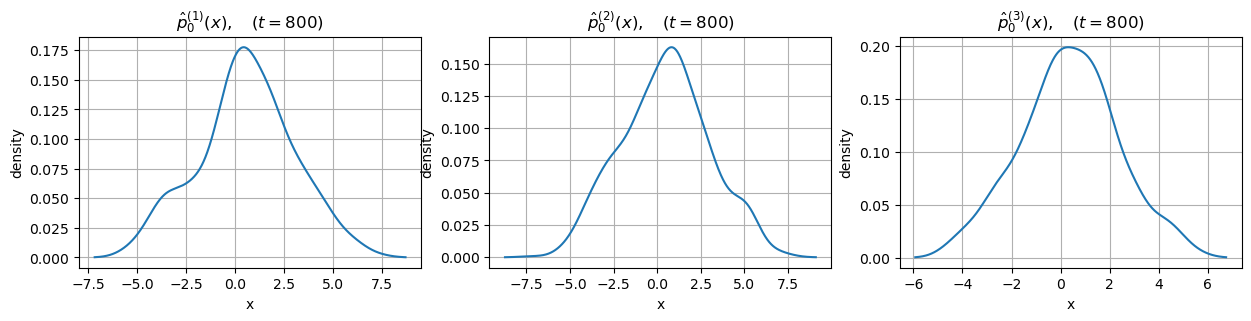

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3))

for j in range(3):
    axes[j].plot(x_grids_t[j], p0_grids_t[j])
    axes[j].set_title(rf"$\hat p_{{0}}^{{({j+1})}}(x),\quad (t=800)$")
    axes[j].set_xlabel("x")
    axes[j].set_ylabel("density")
    axes[j].grid(True)

plt.show()

**Estimated marginal CDF**

$$
\hat P_t^{(1)}(x),\qquad \hat P_t^{(2)}(x),\qquad \hat P_t^{(3)}(x)
$$


In [14]:
print(len(P_grids_t[0]))  # X^(1) estimated marginal CDF
print(len(P_grids_t[1]))  # X^(2) estimated marginal CDF
print(len(P_grids_t[2]))  # X^(3) estimated marginal CDF

1000
1000
1000


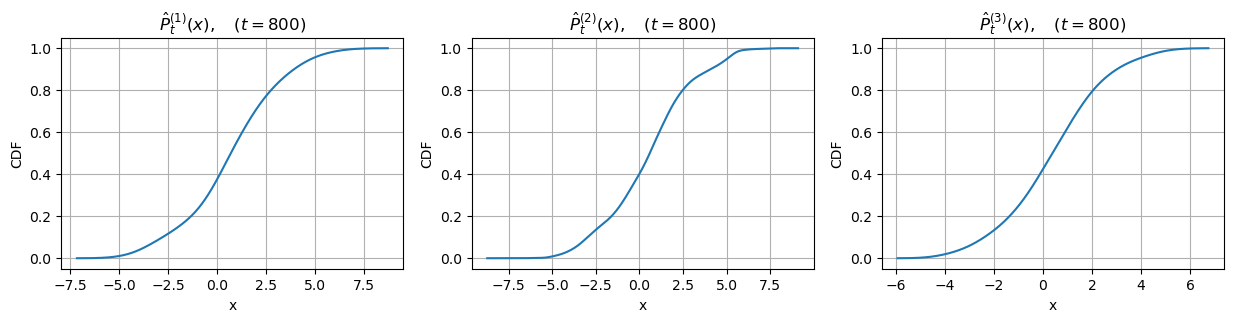

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3))

for j in range(3):
    axes[j].plot(x_grids_t[j], P_grids_t[j])
    axes[j].set_title(rf"$\hat P_{{t}}^{{({j+1})}}(x),\quad (t=800)$")
    axes[j].set_xlabel("x")
    axes[j].set_ylabel("CDF")
    axes[j].grid(True)

plt.show()

$$
U_i^{(j)}=\hat P_t^{(j)}\left(X_i^{(j)}\right) \in[0,1],
\qquad i=1,\ldots,t,\quad j=1,2,3.
$$

<br>

$$
\mathbf{U}
= \begin{pmatrix}
\hat P_t^{(1)}(X_1^{(1)}) & \hat P_t^{(2)}(X_1^{(2)}) & \hat P_t^{(3)}(X_1^{(3)}) \\
\vdots & \vdots & \vdots \\
\hat P_t^{(1)}(X_{t}^{(1)}) & \hat P_t^{(2)}(X_{t}^{(2)}) & \hat P_t^{(3)}(X_{t}^{(3)})
\end{pmatrix}
= \begin{pmatrix}
U_1^{(1)} & U_1^{(2)} & U_1^{(3)} \\
\vdots & \vdots & \vdots \\
U_{t}^{(1)} & U_{t}^{(2)} & U_{t}^{(3)}
\end{pmatrix}
$$

In [16]:
U_train_t = X_to_U(X=X_train, x_grids=x_grids_t, P_grids=P_grids_t)
U_target_t = X_to_U(X=X_target, x_grids=x_grids_t, P_grids=P_grids_t)

In [17]:
print(U_train_t.shape)
print(U_target_t.shape)
U_train_t.min(), U_train_t.max()

(800, 3)
(1, 3)


(np.float64(0.00027552180320283685), np.float64(0.9995918357956601))

## **Conditional marginal density**

In [18]:
k = 3

U_condition_train, U_target_train = lagged_k_U(U_train_t, k)

$$
U_{\text{condition\_train}}
=\begin{pmatrix}
U_3^{(1)} & U_3^{(2)} & U_3^{(3)} \qquad
&
U_2^{(1)} & U_2^{(2)} & U_2^{(3)}\qquad
&
U_1^{(1)} & U_1^{(2)} & U_1^{(3)}
\\
U_4^{(1)} & U_4^{(2)} & U_4^{(3)}\qquad
&
U_3^{(1)} & U_3^{(2)} & U_3^{(3)}\qquad
&
U_2^{(1)} & U_2^{(2)} & U_2^{(3)}
\\
U_5^{(1)} & U_5^{(2)} & U_5^{(3)}\qquad
&
U_4^{(1)} & U_4^{(2)} & U_4^{(3)}\qquad
&
U_3^{(1)} & U_3^{(2)} & U_3^{(3)}
\\
\vdots & \vdots & \vdots
&
\vdots & \vdots & \vdots
&
\vdots & \vdots & \vdots
\\
U_{798}^{(1)} & U_{798}^{(2)} & U_{798}^{(3)}
&
U_{797}^{(1)} & U_{797}^{(2)} & U_{797}^{(3)}
&
U_{796}^{(1)} & U_{796}^{(2)} & U_{796}^{(3)}
\\
U_{799}^{(1)} & U_{799}^{(2)} & U_{799}^{(3)}
&
U_{798}^{(1)} & U_{798}^{(2)} & U_{798}^{(3)}
&
U_{797}^{(1)} & U_{797}^{(2)} & U_{797}^{(3)}
\end{pmatrix}
$$

<br>

$$
U_{\text{target\_train}}
=\begin{pmatrix}
U_4^{(1)} & U_4^{(2)} & U_4^{(3)}
\\
U_5^{(1)} & U_5^{(2)} & U_5^{(3)}
\\
U_6^{(1)} & U_6^{(2)} & U_6^{(3)}
\\
\vdots & \vdots & \vdots
\\
U_{799}^{(1)} & U_{799}^{(2)} & U_{799}^{(3)}
\\
U_{800}^{(1)} & U_{800}^{(2)} & U_{800}^{(3)}
\end{pmatrix}.
$$

In [19]:
U_condition_train

array([[0.37782223, 0.24528454, 0.18288471, ..., 0.59543306, 0.31846944,
        0.46691142],
       [0.24528454, 0.18288471, 0.21384373, ..., 0.31846944, 0.46691142,
        0.29057562],
       [0.18288471, 0.21384373, 0.17673284, ..., 0.46691142, 0.29057562,
        0.38093856],
       ...,
       [0.96571485, 0.95737736, 0.95196893, ..., 0.94535042, 0.92790808,
        0.92037108],
       [0.95737736, 0.95196893, 0.88096649, ..., 0.92790808, 0.92037108,
        0.9184261 ],
       [0.95196893, 0.88096649, 0.84175049, ..., 0.92037108, 0.9184261 ,
        0.91481314]])

In [20]:
U_target_train

array([[0.21384373, 0.0652466 , 0.29057562],
       [0.17673284, 0.17180803, 0.38093856],
       [0.2773314 , 0.70524711, 0.15805625],
       ...,
       [0.88096649, 0.94981638, 0.9184261 ],
       [0.84175049, 0.91735094, 0.91481314],
       [0.95119447, 0.94285906, 0.95003283]])

In [21]:
print(U_condition_train.shape)
print(U_target_train.shape)

(797, 9)
(797, 3)



the most recent three observations are used for predicting $U_{801}$ 

**u_condition_pred**

$$
\begin{pmatrix}
U_{798}^{(1)} & U_{798}^{(2)} & U_{798}^{(3)} \qquad \quad
U_{799}^{(1)} & U_{799}^{(2)} & U_{799}^{(3)} \qquad \quad
U_{800}^{(1)} & U_{800}^{(2)} & U_{800}^{(3)}
\end{pmatrix}
$$


In [22]:
u_condition_pred = U_train_t[-k:, :].T.reshape(-1)

**vine copula**

In [23]:
vines_t = fit_conditional_vines(U_condition=U_condition_train, U_target=U_target_train)

$$
\text{vine}_1\quad:\quad \hat c_{vine}^{(1)}
\left(U_{t+1}^{(1)}, U_t, U_{t-1}, U_{t-2}\right)
$$

$$
\text{vine}_2\quad:\quad\hat c_{vine}^{(2)}
\left(U_{t+1}^{(2)}, U_t, U_{t-1}, U_{t-2}\right)
$$

$$
\text{vine}_3\quad:\quad \hat c_{vine}^{(3)}
\left(U_{t+1}^{(3)}, U_t, U_{t-1}, U_{t-2}\right)
$$

In [24]:
vines_t

[<pyvinecopulib.Vinecop> Vinecop model with 10 variables
 tree edge conditioned variables  conditioning variables var_types       family rotation parameters  df  tau 
    1    1                  7, 4                              c, c     Gaussian        0       0.86 1.0 0.67 
    1    2                  5, 2                              c, c     Gaussian        0       0.86 1.0 0.66 
    1    3                  2, 3                              c, c     Gaussian        0       0.89 1.0 0.70 
    1    4                  1, 4                              c, c     Gaussian        0       0.89 1.0 0.70 
    1    5                  6, 3                              c, c     Gaussian        0       0.86 1.0 0.66 
    1    6                  3, 4                              c, c     Gaussian        0       0.89 1.0 0.70 
    1    7                  8, 9                              c, c     Gaussian        0       0.88 1.0 0.68 
    1    8                 4, 10                              c

spline density 

**conditional marginal PDF,CDF curves**

conditional marginal PDF curve :
$
\widehat c_{\mathrm{cond}}^{(j)}
\left(y \mid \mathcal F_t\right)
=\widehat c^{(j)}(y)\cdot\displaystyle\frac{\widehat c_{vine}^{(j)}\left(\widehat P^{(j)}(y),u_{\mathrm{condition}}\right)
}{
\displaystyle\int_0^1\widehat c_{vine}^{(j)}\left(s,u_{\mathrm{condition}}\right)\,ds}
$

<br>

$$
c_{\mathrm{cond\_curves}}[j]
=\left(
\hat c_{\mathrm{cond}}^{(j)}\left(y_1^{(j)} \mid \mathcal F_t\right),\hat c_{\mathrm{cond}}^{(j)}
\left(y_2^{(j)} \mid \mathcal F_t\right),\ldots,\hat c_{\mathrm{cond}}^{(j)}
\left(y_m^{(j)} \mid \mathcal F_t\right)\right)
$$


<br>

conditional marginal CDF curve : $
\widehat C_{\mathrm{cond}}^{(j)}
\left(y \mid \mathcal F_t\right)
=\frac{\displaystyle\int_0^{\widehat P^{(j)}(y)}\widehat c_{vine}^{(j)}\left(s,u_{\mathrm{condition}}\right)\,ds
}{
\displaystyle\int_0^1\widehat c_{vine}^{(j)}\left(s,u_{\mathrm{condition}}\right)\,ds}
$

<br>

$$
C_{\mathrm{cond\_curves}}[j]
=\left(\hat C_{\mathrm{cond}}^{(j)}
\left(y_1^{(j)} \mid \mathcal F_t\right),\hat C_{\mathrm{cond}}^{(j)}
\left(y_2^{(j)} \mid \mathcal F_t\right),\ldots,\hat C_{\mathrm{cond}}^{(j)}
\left(y_m^{(j)} \mid \mathcal F_t\right)\right)
$$

### plot

In [25]:
p_cond_mal_pdf = []
P_cond_mal_cdf = []

for j in range(3):

    y_grid_j = x_grids_t[j]

    # conditional marginal PDF curve
    p_cond_mal_pdf_j = []

    for y_val in y_grid_j:

        p_cond_val = conditional_marginal_pdf(y_j=y_val, vine_j=vines_t[j], u_condition=u_condition_pred, 
                                              x_grid_j=x_grids_t[j], p_grid_j=p_grids_t[j], P_grid_j=P_grids_t[j])

        p_cond_mal_pdf_j.append(p_cond_val)

    p_cond_mal_pdf_j = np.array(p_cond_mal_pdf_j)


    # conditional marginal CDF curve
    P_cond_mal_cdf_j = []

    for y_val in y_grid_j:

        P_cond_val = conditional_marginal_cdf(y_j=y_val, vine_j=vines_t[j], u_condition=u_condition_pred,
                                              x_grid_j=x_grids_t[j], P_grid_j=P_grids_t[j])

        P_cond_mal_cdf_j.append(P_cond_val)

    P_cond_mal_cdf_j = np.array(P_cond_mal_cdf_j)


    p_cond_mal_pdf.append(p_cond_mal_pdf_j)
    P_cond_mal_cdf.append(P_cond_mal_cdf_j)

In [26]:
len(p_cond_mal_pdf)

3

In [27]:
print(len(P_cond_mal_cdf[1]))
print(len(P_cond_mal_cdf))

1000
3


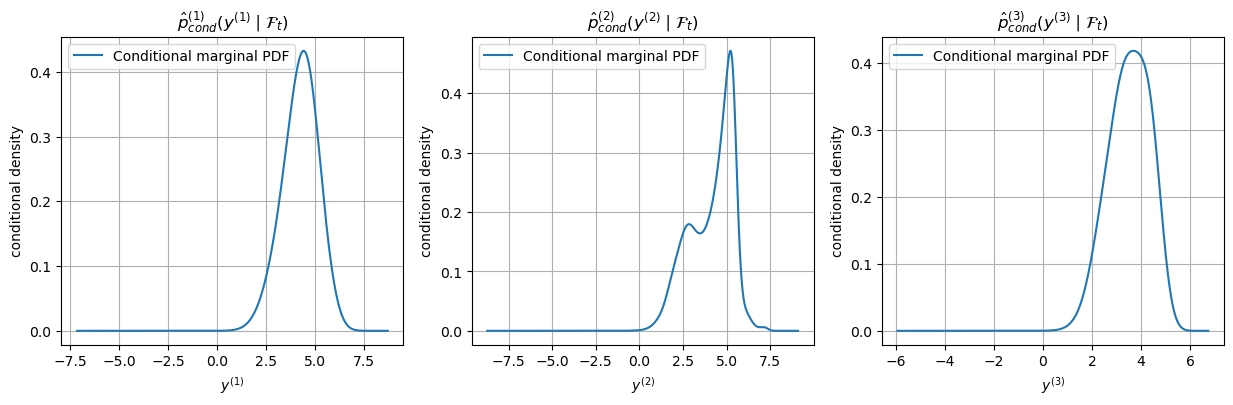

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for j in range(3):

    axes[j].plot(
        x_grids_t[j],
        p_cond_mal_pdf[j],
        label="Conditional marginal PDF"
    )

    axes[j].set_title(
        rf"$\hat p_{{cond}}^{{({j+1})}}(y^{{({j+1})}}\mid \mathcal{{F}}_t)$"
    )
    axes[j].set_xlabel(rf"$y^{{({j+1})}}$")
    axes[j].set_ylabel("conditional density")
    axes[j].legend()
    axes[j].grid(True)

plt.show()

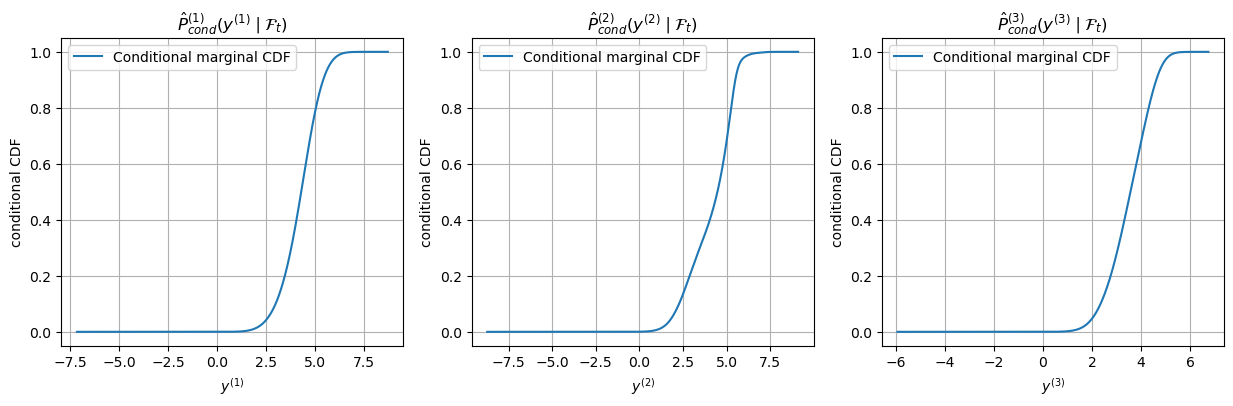

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for j in range(3):

    axes[j].plot(
        x_grids_t[j],
        P_cond_mal_cdf[j],
        label="Conditional marginal CDF"
    )

    axes[j].set_title(
        rf"$\hat P_{{cond}}^{{({j+1})}}(y^{{({j+1})}}\mid \mathcal{{F}}_t)$"
    )
    axes[j].set_xlabel(rf"$y^{{({j+1})}}$")
    axes[j].set_ylabel("conditional CDF")
    axes[j].legend()
    axes[j].grid(True)


plt.show()

## **$\widetilde{\mathbf{U}}$**

$$
\widetilde U_i^{(j)}=\hat P_t^{(j)}\left(X_i^{(j)} | \ \mathcal{F}_t\right) \in[0,1],
\qquad i=k+1,\ldots,t,\quad j=1,2,3.
$$

$$
\widetilde{\mathbf{U}}_{\mathrm{train}}=
\begin{pmatrix}
\widetilde{U}_{4}^{(1)} &
\widetilde{U}_{4}^{(2)} &
\widetilde{U}_{4}^{(3)}
\\
\vdots & \vdots & \vdots
\\
\widetilde{U}_{800}^{(1)} &
\widetilde{U}_{800}^{(2)} &
\widetilde{U}_{800}^{(3)}
\end{pmatrix}
\in (0,1)^{797 \times 3}.
$$

In [30]:
X_target_train = X_train[k:]

In [31]:
p_cond_train, U_tilde_train = build_u_tilde_data(X_target=X_target_train, U_condition=U_condition_train, vines=vines_t,
                                                 x_grids=x_grids_t, p_grids=p_grids_t, P_grids=P_grids_t)

In [32]:
U_tilde_train.shape

(797, 3)

In [33]:
U_tilde_train

array([[0.32598165, 0.06167984, 0.4631829 ],
       [0.4233207 , 0.5382533 , 0.70167778],
       [0.67883403, 0.99725662, 0.21171525],
       ...,
       [0.17724987, 0.6407077 , 0.39120599],
       [0.17007347, 0.45696936, 0.54001682],
       [0.85975508, 0.77493971, 0.82468503]])

## **Time-varying copula**

$$
\widetilde{\mathbf U}_{\mathrm{train}}
=
\begin{pmatrix}
\widetilde U_{4}^{(1)} & \widetilde U_{4}^{(2)} & \widetilde U_{4}^{(3)}\\
\vdots & \vdots & \vdots\\
\widetilde U_{800}^{(1)} & \widetilde U_{800}^{(2)} & \widetilde U_{800}^{(3)}
\end{pmatrix}
\in(0,1)^{797\times3}.
$$

$$
\widetilde{\mathbf U}_i
=
\begin{pmatrix}
\widetilde U_i^{(1)}\\
\widetilde U_i^{(2)}\\
\widetilde U_i^{(3)}
\end{pmatrix}
\in(0,1)^3,
\qquad
i=4,\ldots,800.
$$

$$
c_{\mathrm{mix},i}
\!\left(\widetilde{\mathbf U}_i\right)
=
w\,
c_G\!\left(\widetilde{\mathbf U}_i;\mathbf R_i\right)
+
(1-w)\,
c_C\!\left(\widetilde{\mathbf U}_i;\theta_i\right).
$$

$$
\widehat{\Theta}
=
\arg\max_{\Theta}
\sum_{i=4}^{800}
\log
c_{\mathrm{mix},i}
\!\left(\widetilde{\mathbf U}_i\right).
$$



In [34]:
estimated_parameters = estimate_gaussian_clayton_gas(U_tilde_train, epochs=300, learning_rate=0.0001)

In [35]:
estimated_parameters #22.30 - 26:00

{'weight': tensor(0.0057, dtype=torch.float64),
 'omega_G': tensor([0.0281, 0.0233, 0.0260], dtype=torch.float64),
 'A_G': tensor([ 0.0213,  0.0117, -0.0091], dtype=torch.float64),
 'B_G': tensor([0.9038, 0.9033, 0.9037], dtype=torch.float64),
 'omega_C': tensor(-0.0216, dtype=torch.float64),
 'A_C': tensor(-0.0254, dtype=torch.float64),
 'B_C': tensor(0.9034, dtype=torch.float64)}

In [36]:
time_varying_copula_paths = compute_time_varying_copula_paths( U_tilde_train, estimated_parameters)

In [37]:
time_varying_copula_parameters["weight"]

NameError: name 'time_varying_copula_parameters' is not defined

In [38]:
time_varying_copula_parameters["R_path"].shape

NameError: name 'time_varying_copula_parameters' is not defined

In [ ]:
time_varying_copula_parameters["theta_path"].shape

In [39]:
mixture_copula_results = compute_time_varying_copula_paths(U_tilde_train,estimated_parameters)

In [40]:
mixture_copula_results

{'weight': tensor(0.5014, dtype=torch.float64),
 'R_path': tensor([[[1.0000, 0.0000, 0.0000],
          [0.0000, 1.0000, 0.0000],
          [0.0000, 0.0000, 1.0000]],
 
         [[1.0000, 0.0166, 0.0117],
          [0.0166, 1.0000, 0.0130],
          [0.0117, 0.0130, 1.0000]],
 
         [[1.0000, 0.0290, 0.0221],
          [0.0290, 1.0000, 0.0251],
          [0.0221, 0.0251, 1.0000]],
 
         ...,
 
         [[1.0000, 0.1409, 0.1439],
          [0.1409, 1.0000, 0.1566],
          [0.1439, 0.1566, 1.0000]],
 
         [[1.0000, 0.1373, 0.1428],
          [0.1373, 1.0000, 0.1546],
          [0.1428, 0.1546, 1.0000]],
 
         [[1.0000, 0.1396, 0.1403],
          [0.1396, 1.0000, 0.1536],
          [0.1403, 0.1536, 1.0000]]], dtype=torch.float64),
 'theta_path': tensor([1.0000, 0.9911, 0.9672, 0.9592, 0.9364, 0.9192, 0.9111, 0.8998, 0.8962,
         0.8832, 0.8732, 0.8642, 0.8436, 0.8330, 0.8317, 0.8299, 0.8350, 0.8438,
         0.8256, 0.8272, 0.8307, 0.8361, 0.8261, 0.8164, 0.8084

In [41]:
mixture_copula_results['copula_density_path'].shape

torch.Size([797])

## **Conditional joint density**

In [45]:
mixture_copula_results = compute_time_varying_copula_paths(U_tilde_train, estimated_parameters)

In [46]:
R_next = mixture_copula_results["R_next"]
theta_next = mixture_copula_results["theta_next"]
weight = mixture_copula_results["weight"]

print("R_next:")
print(R_next)

print("theta_next:")
print(theta_next)

print("weight:")
print(weight)

R_next:
tensor([[1.0000, 0.1453, 0.1424],
        [0.1453, 1.0000, 0.1528],
        [0.1424, 0.1528, 1.0000]], dtype=torch.float64)
theta_next:
tensor(0.7471, dtype=torch.float64)
weight:
tensor(0.5014, dtype=torch.float64)


In [47]:
y = X_target[0]

estimated_density = predictive_density(
    y=y,
    vines=vines_t,
    u_condition=u_condition_pred,
    x_grids=x_grids_t,
    p_grids=p_grids_t,
    P_grids=P_grids_t,
    R_next=R_next,
    theta_next=theta_next,
    weight=weight
)

print("y:")
print(y)

print("Estimated predictive density:")
print(estimated_density)

y:
[3.81089663 2.78414067 4.21690918]
Estimated predictive density:
0.021571329814671494


In [48]:
true_density = true_var3_3d_conditional_density(
    y=y,
    x_t=X_train[-1],
    x_t_minus_1=X_train[-2],
    x_t_minus_2=X_train[-3],
    A1=A1,
    A2=A2,
    A3=A3,
    Sigma=Sigma
)

print("Estimated density:", estimated_density)
print("True density:     ", true_density)

Estimated density: 0.021571329814671494
True density:      0.011741833760873597


In [49]:
p_cond, u_tilde = conditional_marginal_all(
    y=y,
    vines=vines_t,
    u_condition=u_condition_pred,
    x_grids=x_grids_t,
    p_grids=p_grids_t,
    P_grids=P_grids_t
)

print("Conditional marginal densities:")
print(p_cond)

print("Conditional PITs:")
print(u_tilde)

print("Product of conditional marginal densities:")
print(np.prod(p_cond))

Conditional marginal densities:
[0.35580051 0.17920153 0.38568636]
Conditional PITs:
[0.31535991 0.18320174 0.76552427]
Product of conditional marginal densities:
0.024591360453213067


In [50]:
# true conditional mean at t+1
mean_cond = (
    A1 @ X_train[-1]
    + A2 @ X_train[-2]
    + A3 @ X_train[-3]
)

print("True conditional mean:")
print(mean_cond)

True conditional mean:
[4.26095279 4.38489647 3.56465529]


In [51]:
rng = np.random.default_rng(123)

n_eval = 20

Y_eval = rng.multivariate_normal(
    mean=mean_cond,
    cov=Sigma,
    size=n_eval
)

Y_eval.shape

(20, 3)

In [52]:
estimated_densities = []
true_densities = []

for y_eval in Y_eval:

    estimated = predictive_density(
        y=y_eval,
        vines=vines_t,
        u_condition=u_condition_pred,
        x_grids=x_grids_t,
        p_grids=p_grids_t,
        P_grids=P_grids_t,
        R_next=R_next,
        theta_next=theta_next,
        weight=weight
    )

    true = true_var3_3d_conditional_density(
        y=y_eval,
        x_t=X_train[-1],
        x_t_minus_1=X_train[-2],
        x_t_minus_2=X_train[-3],
        A1=A1,
        A2=A2,
        A3=A3,
        Sigma=Sigma
    )

    estimated_densities.append(estimated)
    true_densities.append(true)

estimated_densities = np.array(estimated_densities)
true_densities = np.array(true_densities)

In [53]:
for i in range(n_eval):
    print(
        f"{i:2d} | "
        f"estimated = {estimated_densities[i]:.6f} | "
        f"true = {true_densities[i]:.6f}"
    )

 0 | estimated = 0.040011 | true = 0.018974
 1 | estimated = 0.029918 | true = 0.041286
 2 | estimated = 0.060583 | true = 0.050895
 3 | estimated = 0.031912 | true = 0.022384
 4 | estimated = 0.008025 | true = 0.018051
 5 | estimated = 0.014022 | true = 0.018702
 6 | estimated = 0.009936 | true = 0.005972
 7 | estimated = 0.021101 | true = 0.008701
 8 | estimated = 0.014858 | true = 0.024832
 9 | estimated = 0.032155 | true = 0.039465
10 | estimated = 0.030726 | true = 0.015726
11 | estimated = 0.000820 | true = 0.006609
12 | estimated = 0.018100 | true = 0.006784
13 | estimated = 0.022663 | true = 0.025176
14 | estimated = 0.018613 | true = 0.021492
15 | estimated = 0.097566 | true = 0.057172
16 | estimated = 0.006493 | true = 0.004259
17 | estimated = 0.050509 | true = 0.075713
18 | estimated = 0.074579 | true = 0.039310
19 | estimated = 0.009810 | true = 0.015090


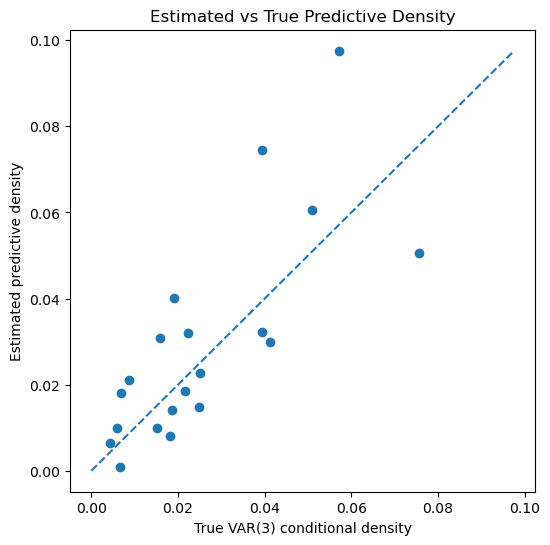

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

plt.scatter(
    true_densities,
    estimated_densities
)

max_density = max(
    true_densities.max(),
    estimated_densities.max()
)

plt.plot(
    [0, max_density],
    [0, max_density],
    linestyle="--"
)

plt.xlabel("True VAR(3) conditional density")
plt.ylabel("Estimated predictive density")
plt.title("Estimated vs True Predictive Density")

plt.show()

In [55]:
mae = np.mean(
    np.abs(estimated_densities - true_densities)
)

correlation = np.corrcoef(
    true_densities,
    estimated_densities
)[0, 1]

print("Mean absolute density difference:", mae)
print("Correlation:", correlation)

Mean absolute density difference: 0.012292782874331316
Correlation: 0.7624676383245963


**원인 분석**

In [58]:
mean_cond_true = true_var3_3d_conditional_mean(
    x_t=X_train[-1],
    x_t_minus_1=X_train[-2],
    x_t_minus_2=X_train[-3],
    A1=A1,
    A2=A2,
    A3=A3
)

print("True conditional mean:")
print(mean_cond_true)

True conditional mean:
[4.26095279 4.38489647 3.56465529]


In [59]:
p_cond_est, u_tilde_est = conditional_marginal_all(
    y=y,
    vines=vines_t,
    u_condition=u_condition_pred,
    x_grids=x_grids_t,
    p_grids=p_grids_t,
    P_grids=P_grids_t
)

print("Estimated conditional marginal densities:")
print(p_cond_est)

Estimated conditional marginal densities:
[0.35580051 0.17920153 0.38568636]


In [60]:
p_cond_true = np.array([
    true_var3_3d_conditional_marginal_pdf(
        y_j=y[j],
        j=j,
        mean_cond=mean_cond_true,
        Sigma=Sigma
    )
    for j in range(3)
])

print("True conditional marginal densities:")
print(p_cond_true)

True conditional marginal densities:
[0.36051785 0.13864885 0.35187358]


In [61]:
print("                Estimated        True")
for j in range(3):
    print(
        f"Margin {j + 1}:     "
        f"{p_cond_est[j]:.6f}       "
        f"{p_cond_true[j]:.6f}"
    )

                Estimated        True
Margin 1:     0.355801       0.360518
Margin 2:     0.179202       0.138649
Margin 3:     0.385686       0.351874


In [62]:
P_cond_true = np.array([
    true_var3_3d_conditional_marginal_cdf(
        y_j=y[j],
        j=j,
        mean_cond=mean_cond_true,
        Sigma=Sigma
    )
    for j in range(3)
])

print("True conditional marginal CDFs:")
print(P_cond_true)

True conditional marginal CDFs:
[0.32633497 0.09560438 0.78218462]


In [63]:
print("                Estimated        True")
for j in range(3):
    print(
        f"Margin {j + 1}:     "
        f"{u_tilde_est[j]:.6f}       "
        f"{P_cond_true[j]:.6f}"
    )

                Estimated        True
Margin 1:     0.315360       0.326335
Margin 2:     0.183202       0.095604
Margin 3:     0.765524       0.782185


In [64]:
u_tilde_true = true_var3_3d_conditional_pit(
    y=y,
    mean_cond=mean_cond_true,
    Sigma=Sigma
)

print("Estimated conditional PITs:")
print(u_tilde_est)

print("True conditional PITs:")
print(u_tilde_true)

Estimated conditional PITs:
[0.31535991 0.18320174 0.76552427]
True conditional PITs:
[0.32633497 0.09560438 0.78218462]


In [65]:
print("PIT differences:")
print(u_tilde_est - u_tilde_true)

PIT differences:
[-0.01097506  0.08759736 -0.01666035]


In [66]:
R_true = true_gaussian_copula_correlation(Sigma)

print("True Gaussian copula correlation:")
print(R_true)

print()

print("Estimated Gaussian component R_next:")
print(R_next)

True Gaussian copula correlation:
[[1.         0.40824829 0.35856858]
 [0.40824829 1.         0.39036003]
 [0.35856858 0.39036003 1.        ]]

Estimated Gaussian component R_next:
tensor([[1.0000, 0.1453, 0.1424],
        [0.1453, 1.0000, 0.1528],
        [0.1424, 0.1528, 1.0000]], dtype=torch.float64)


In [67]:
print("Pair (1,2)")
print("Estimated:", R_next[0, 1].item())
print("True:     ", R_true[0, 1])

print()

print("Pair (1,3)")
print("Estimated:", R_next[0, 2].item())
print("True:     ", R_true[0, 2])

print()

print("Pair (2,3)")
print("Estimated:", R_next[1, 2].item())
print("True:     ", R_true[1, 2])

Pair (1,2)
Estimated: 0.14525218490470318
True:      0.4082482904638631

Pair (1,3)
Estimated: 0.14239558417183415
True:      0.35856858280031806

Pair (2,3)
Estimated: 0.15280110186915558
True:      0.39036002917941337


### **MH**

In [69]:
required_objects = [
    "X_train",
    "vines_t",
    "u_condition_pred",
    "x_grids_t",
    "p_grids_t",
    "P_grids_t",
    "R_next",
    "theta_next",
    "weight",
]

missing_objects = [
    name for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise NameError(
        f"Missing fitted VAR(3) objects: {missing_objects}. "
        "Run these cells in the kernel where the VAR(3) fitting is complete."
    )

for name in required_objects:
    value = globals()[name]
    print(
        f"{name}: type={type(value).__name__}, "
        f"shape={getattr(value, 'shape', None)}"
    )

X_train: type=ndarray, shape=(800, 3)
vines_t: type=list, shape=None
u_condition_pred: type=ndarray, shape=(9,)
x_grids_t: type=list, shape=None
p_grids_t: type=list, shape=None
P_grids_t: type=list, shape=None
R_next: type=Tensor, shape=torch.Size([3, 3])
theta_next: type=Tensor, shape=torch.Size([])
weight: type=Tensor, shape=torch.Size([])


In [70]:
def target(y):
    return predictive_density(
        y=y,
        vines=vines_t,
        u_condition=u_condition_pred,
        x_grids=x_grids_t,
        p_grids=p_grids_t,
        P_grids=P_grids_t,
        R_next=R_next,
        theta_next=theta_next,
        weight=weight
    )

In [71]:
initial_position = np.asarray(X_train[-1], dtype=float)
initial_density = float(target(initial_position))

print("Initial position:")
print(initial_position)

print("Target density at initial position:")
print(initial_density)

target_is_valid = (
    np.isfinite(initial_density)
    and initial_density > 0.0
)

if not target_is_valid:
    raise ValueError(
        "target(X_train[-1]) must return a finite positive density, "
        f"but received {initial_density}."
    )

print("Finite positive target density: True")

Initial position:
[4.83993428 4.92220905 3.8942192 ]
Target density at initial position:
0.08430731529587863
Finite positive target density: True


In [72]:
proposal = mvn_def()
random_proposal = sample_mvn()

In [73]:
if not globals().get("target_is_valid", False):
    raise RuntimeError(
        "Run the finite-positive target density check successfully first."
    )

chain = metropolis_hastings(
    target=target,
    proposal=proposal,
    random_proposal=random_proposal,
    initial_position=initial_position,
    chain_length=500,
    burn_in=100
)

In [74]:
chain_is_finite = bool(np.isfinite(chain).all())
state_changed = np.any(np.diff(chain, axis=0) != 0.0, axis=1)
acceptance_rate = float(np.mean(state_changed))

print("Chain shape:")
print(chain.shape)

print("First five samples:")
print(chain[:5])

print("All chain values finite:")
print(chain_is_finite)

print("Post-burn-in state-change acceptance rate:")
print(acceptance_rate)

Chain shape:
(400, 3)
First five samples:
[[2.74491509 4.75581184 1.89181642]
 [2.74491509 4.75581184 1.89181642]
 [2.74491509 4.75581184 1.89181642]
 [2.74491509 4.75581184 1.89181642]
 [3.1738581  3.87185274 3.08348702]]
All chain values finite:
True
Post-burn-in state-change acceptance rate:
0.38345864661654133


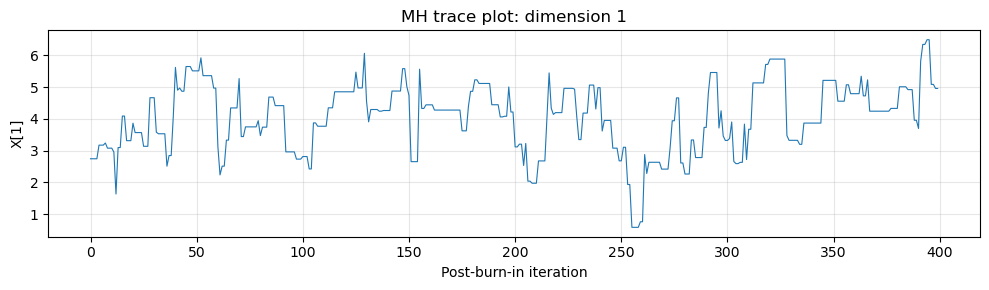

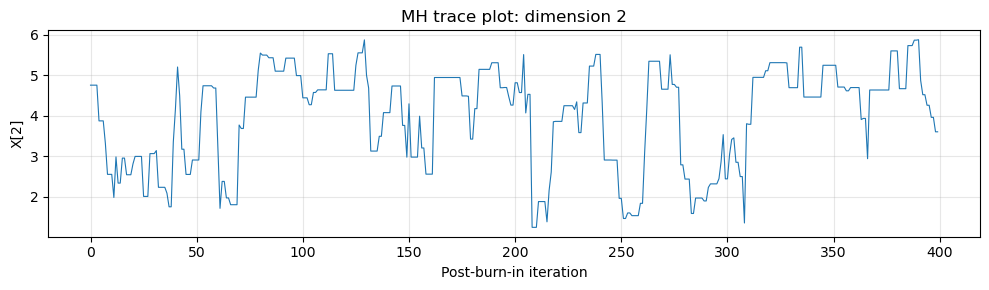

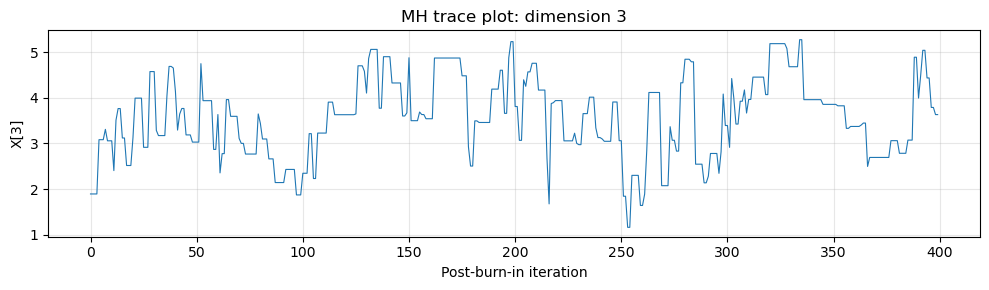

In [75]:
for j in range(3):

    plt.figure(figsize=(10, 3))

    plt.plot(
        chain[:, j],
        linewidth=0.8
    )

    plt.title(f"MH trace plot: dimension {j + 1}")
    plt.xlabel("Post-burn-in iteration")
    plt.ylabel(f"X[{j + 1}]")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [76]:
chain_long = metropolis_hastings(
    target=target,
    proposal=proposal,
    random_proposal=random_proposal,
    initial_position=initial_position,
    chain_length=3000,
    burn_in=500
)

In [77]:
chain_long_is_finite = bool(
    np.isfinite(chain_long).all()
)

state_changed_long = np.any(
    np.diff(chain_long, axis=0) != 0.0,
    axis=1
)

state_change_rate_long = float(
    np.mean(state_changed_long)
)

print("chain_long shape:")
print(chain_long.shape)

print("\nFirst five samples:")
print(chain_long[:5])

print("\nAll chain values finite:")
print(chain_long_is_finite)

print("\nPost-burn-in state-change rate:")
print(state_change_rate_long)

chain_long shape:
(2500, 3)

First five samples:
[[5.01102441 5.88744539 4.51934854]
 [5.01102441 5.88744539 4.51934854]
 [4.37700264 3.92142361 4.02856698]
 [3.77023525 4.70931975 4.44766074]
 [4.12298904 4.47149685 3.71764916]]

All chain values finite:
True

Post-burn-in state-change rate:
0.37254901960784315


In [78]:
true_mean_next = true_var3_3d_conditional_mean(
    x_t=X_train[-1],
    x_t_minus_1=X_train[-2],
    x_t_minus_2=X_train[-3],
    A1=A1,
    A2=A2,
    A3=A3
)

print("True conditional mean:")
print(true_mean_next)

print("\nTrue conditional covariance Sigma:")
print(Sigma)

True conditional mean:
[4.26095279 4.38489647 3.56465529]

True conditional covariance Sigma:
[[1.  0.5 0.3]
 [0.5 1.5 0.4]
 [0.3 0.4 0.7]]


In [79]:
mh_sample_mean = np.mean(
    chain_long,
    axis=0
)

mh_sample_covariance = np.cov(
    chain_long,
    rowvar=False
)

print("MH predictive sample mean:")
print(mh_sample_mean)

print("\nTrue conditional mean:")
print(true_mean_next)

print("\nMH predictive sample covariance:")
print(mh_sample_covariance)

print("\nTrue conditional covariance Sigma:")
print(Sigma)

MH predictive sample mean:
[4.25561119 4.28220402 3.62321741]

True conditional mean:
[4.26095279 4.38489647 3.56465529]

MH predictive sample covariance:
[[0.89758245 0.34335542 0.26350929]
 [0.34335542 1.39430837 0.2287903 ]
 [0.26350929 0.2287903  0.67782294]]

True conditional covariance Sigma:
[[1.  0.5 0.3]
 [0.5 1.5 0.4]
 [0.3 0.4 0.7]]


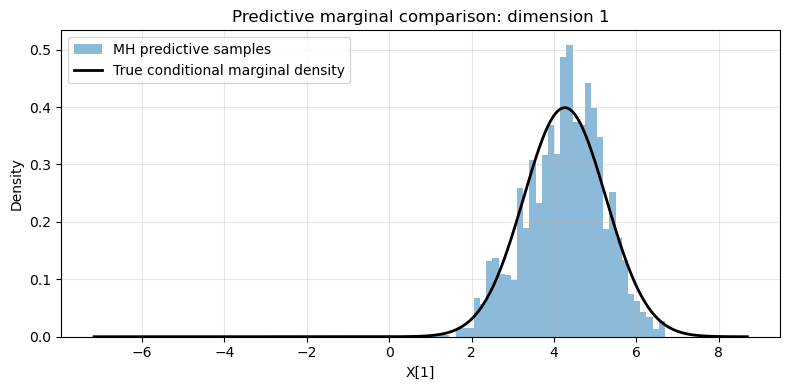

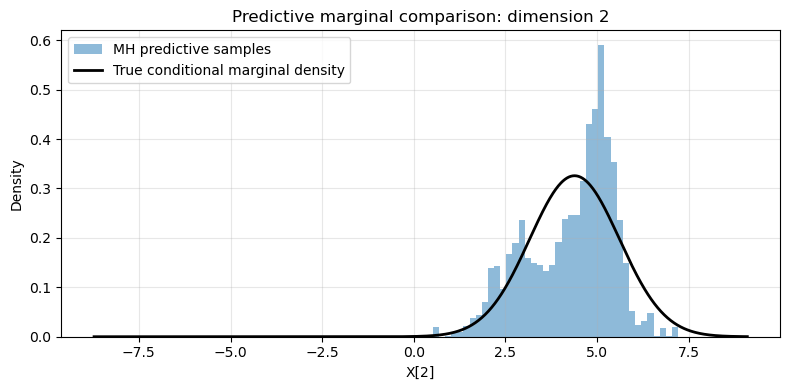

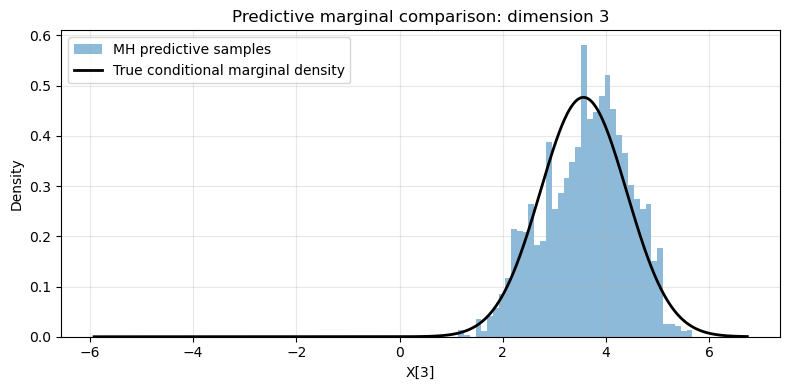

In [81]:
for j in range(3):

    y_grid_j = np.asarray(
        x_grids_t[j],
        dtype=float
    )

    true_pdf_j = np.array([
        true_var3_3d_conditional_marginal_pdf(
            y_j=y_value,
            j=j,
            mean_cond=true_mean_next,
            Sigma=Sigma
        )
        for y_value in y_grid_j
    ])

    plt.figure(figsize=(8, 4))

    plt.hist(
        chain_long[:, j],
        bins=40,
        density=True,
        alpha=0.5,
        label="MH predictive samples"
    )

    plt.plot(
        y_grid_j,
        true_pdf_j,
        color="black",
        linewidth=2,
        label="True conditional marginal density"
    )

    plt.title(
        f"Predictive marginal comparison: dimension {j + 1}"
    )
    plt.xlabel(f"X[{j + 1}]")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()